The purpose of this notebook is to demonstrate why fast timescales require larger and larger source-sink imbalance variability.

In [1]:
from methane_noise_forcing.noise import simulate_two_timescale_ar1
from hydra import compose, initialize
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from methane_noise_forcing.core import FirnFilter
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
)
from methane_noise_forcing.utils import psd_one_sided_cyclic

plt.rcParams.update(matplotlib_rcparams)
fig_width = fig_width_options["two_column_large"]

In [2]:
with initialize(
    version_base=None, config_path="../../../configs"
):  # configs with data paths
    cfg = compose(
        config_name="config",
        overrides=[
            "+noise=white_noise_ar1",
            "++noise.duration_timeseries=4750",
            "+firn_kernel=firn_model_wais",
        ],
    )

In [3]:
def simulate_multiple_realizations(
    taus_varepsilon, var_C_target, tau_C, n_years, dt, n_ensemble
):
    """
    Simulate multiple realizations of methane time series for a single
    methane lifetime across multiple forcing timescales.

    Parameters
    ----------
    taus_varepsilon : sequence of float
        Forcing timescales (years), length F.
    var_C_target : float, 1-D array (F,), or xarray DataArray
        Target methane variance(s) (ppb^2).
        - scalar -> broadcast to (F,)
        - shape (F,) -> used as-is
        - if DataArray with dim 'taus_varepsilon', will be aligned and converted to (F).
    tau_C : float
        Methane lifetime (years).
    n_years : float
        Total simulation length (years).
    dt : float
        Timestep (years).
    n_ensemble : int
        Number of ensemble members.

    Returns
    -------
    xr.Dataset with dims ('taus_varepsilon','ensemble','time')
        Variables: 'ch4' and 'forcing'
    """
    # --- normalize axes
    taus_varepsilon = np.asarray(taus_varepsilon, dtype=float)
    tau_C = float(tau_C)

    F = taus_varepsilon.size

    # --- build time axis
    n_steps = int(np.round(n_years / dt))
    time = np.arange(n_steps) * dt
    ensemble = np.arange(n_ensemble)

    # --- normalize var_C_target to (F,)
    var_array = None

    # If xarray DataArray, try to align by coord names
    try:
        import xarray as xr  # in case this function is used standalone

        if isinstance(var_C_target, xr.DataArray):
            da = var_C_target
            if "taus_varepsilon" in da.dims:
                da = da.sel(
                    taus_varepsilon=xr.DataArray(
                        taus_varepsilon, dims="taus_varepsilon"
                    ),
                    method="nearest",
                )
                var_array = da.values
    except Exception:
        pass

    if var_array is None:
        arr = np.asarray(var_C_target, dtype=float)
        if arr.ndim == 0:
            var_array = np.full(F, float(arr))
        elif arr.ndim == 1:
            if arr.shape[0] != F:
                raise ValueError(
                    f"1-D var_C_target must have length {F} (taus_varepsilon), got {arr.shape[0]}."
                )
            var_array = arr
        else:
            raise ValueError(
                "var_C_target must be scalar, 1-D, or an xarray.DataArray with 'taus_varepsilon' dim."
            )

    # --- simulate
    forcing_blocks = []
    for j, tau_eta in enumerate(taus_varepsilon):
        var_C = float(var_array[j])

        x_ens, eta_ens = simulate_two_timescale_ar1(
            tau_x=tau_C,
            tau_eta=tau_eta,
            variance_x=var_C,
            n_steps=n_steps,
            dt=dt,
            n_ens=n_ensemble,
        )

        ds = xr.Dataset(
            {
                "ch4": (("ensemble", "time"), x_ens),
                "forcing": (("ensemble", "time"), eta_ens),
            },
            coords={"time": time, "ensemble": ensemble},
        ).expand_dims({"taus_varepsilon": [tau_eta]})

        forcing_blocks.append(ds)

    out = xr.concat(forcing_blocks, dim="taus_varepsilon").assign_coords(
        taus_varepsilon=("taus_varepsilon", taus_varepsilon),
    )
    return out

In [8]:
taus_varepsilon = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
tau_C = 10.0
n_ensemble = 100
dt_small = 0.01
n_years = 1000

var_C_target = xr.DataArray(
    np.array(
        [
            277.20946765,
            277.02855622,
            253.71625347,
            163.37931118,
            108.6874886,
            100.99459344,
        ]
    ),
    dims=("taus_varepsilon",),
    coords={
        "taus_varepsilon": taus_varepsilon,
    },
)

two_timescale_noise = simulate_multiple_realizations(
    taus_varepsilon=taus_varepsilon,
    var_C_target=var_C_target,
    tau_C=tau_C,
    n_years=n_years,
    dt=dt_small,
    n_ensemble=n_ensemble,
)

# smooth noise
firn_filter = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
    path_root=cfg.paths.firn_filters_root,
)
noise_smoothed = []
for tau_varepsilon in taus_varepsilon:
    noise_raw = two_timescale_noise.sel(taus_varepsilon=tau_varepsilon)

    noise_smoothed_forcing = []
    for idx_ens in range(n_ensemble):
        ch4_raw = noise_raw.ch4.isel(ensemble=idx_ens).values[:]
        ch4_smooth = firn_filter.apply(ch4_raw, dt_series=dt_small, flip_kernel=True)
        noise_smoothed_forcing.append(ch4_smooth)
    noise_smoothed_forcing = xr.DataArray(
        np.array(noise_smoothed_forcing)[:, :, np.newaxis],
        dims=("ensemble", "time", "taus_varepsilon"),
        coords={
            "ensemble": noise_raw.ensemble,
            "time": noise_raw.time,
            "taus_varepsilon": [tau_varepsilon],
        },
    )
    noise_smoothed.append(noise_smoothed_forcing)
noise_smoothed = xr.concat(noise_smoothed, dim="taus_varepsilon").to_dataset(
    name="ch4_smooth"
)

In [9]:
# Step 1: Standardize variances
# Calculate ensemble mean variance for each timescale
# Then scale so that ch4_smooth has target variance
target_variance_smooth = 100  # ppb

# Combine raw and smoothed data
combined_data = xr.Dataset(
    {
        "ch4": two_timescale_noise.ch4,
        "forcing": two_timescale_noise.forcing,
        "ch4_smooth": noise_smoothed.ch4_smooth,
    }
)

# Calculate ensemble mean variance (over time) for each timescale
var_ch4_smooth = combined_data.ch4_smooth.var(dim="time").mean(dim="ensemble")

# Scale factors to make ch4_smooth have target variance
scale_factors = np.sqrt(target_variance_smooth) / np.sqrt(var_ch4_smooth)

# Apply scaling to all signals for each timescale
scaled_data = xr.Dataset()
for var_name in ["ch4", "forcing", "ch4_smooth"]:
    scaled_data[var_name] = combined_data[var_name] * scale_factors

print("Scaled variance of ch4_smooth (should be ~100.0):")
print(scaled_data.ch4_smooth.var(dim="time").mean(dim="ensemble").values)

Scaled variance of ch4_smooth (should be ~100.0):
[100. 100. 100. 100. 100. 100.]


In [10]:
# Step 2: Calculate ensemble mean power spectra for each signal and timescale

# Storage for power spectra
psd_results = {}

for tau_varepsilon in taus_varepsilon:
    psd_results[tau_varepsilon] = {}

    for var_name in ["forcing", "ch4", "ch4_smooth"]:
        # Get data for this timescale
        data = scaled_data[var_name].sel(taus_varepsilon=tau_varepsilon)

        # Calculate PSD for each ensemble member
        psd_list = []
        for idx_ens in range(n_ensemble):
            signal = data.isel(ensemble=idx_ens).values
            freqs, psd = psd_one_sided_cyclic(signal, dt=dt_small)
            psd_list.append(psd)

        # Ensemble mean PSD
        psd_mean = np.mean(psd_list, axis=0)

        # Exclude zero frequency (to avoid divide by zero)
        mask = freqs > 0
        freqs_nonzero = freqs[mask]
        psd_nonzero = psd_mean[mask]

        # Store results (convert frequency to period)
        periods = 1.0 / freqs_nonzero
        psd_results[tau_varepsilon][var_name] = {"periods": periods, "psd": psd_nonzero}

print("Power spectra calculated for all timescales and signals.")

Power spectra calculated for all timescales and signals.


/tmp/ipykernel_4017719/2137383033.py:53: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  plt.tight_layout(rect=[0.03, 0.03, 1, 1])
/home/disk/p/emei/repos/methane_noise_forcing/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


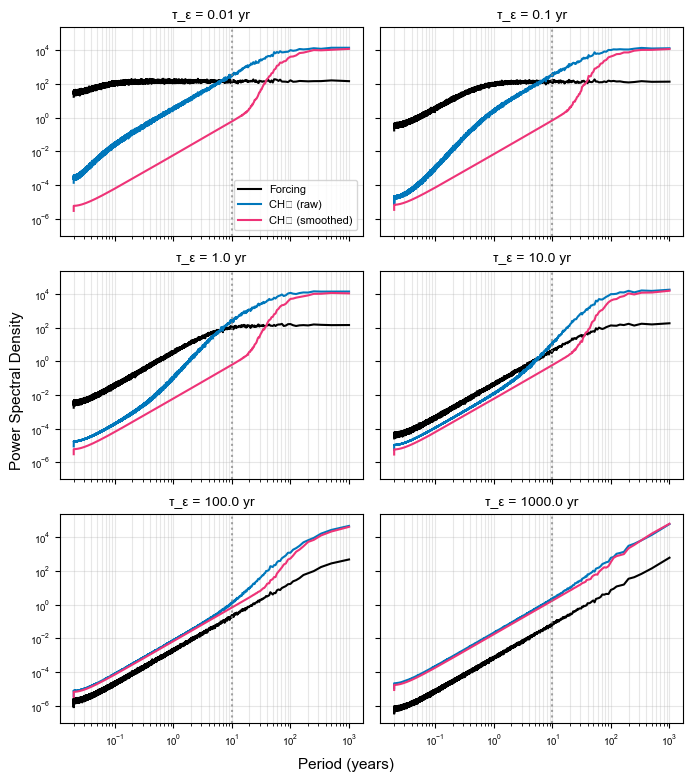

In [11]:
# Step 3: Create plots - one subplot per timescale, arranged in 2 columns

n_timescales = len(taus_varepsilon)
n_cols = 2
n_rows = int(np.ceil(n_timescales / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_width * n_rows / n_cols * 0.75),
    sharex=True,
    sharey=True,
)
axes = axes.flatten()

for idx, tau_varepsilon in enumerate(taus_varepsilon):
    ax = axes[idx]

    # Get power spectra for this timescale
    psd_data = psd_results[tau_varepsilon]

    # Plot forcing (black)
    ax.loglog(
        psd_data["forcing"]["periods"],
        psd_data["forcing"]["psd"],
        color="black",
        linewidth=1.5,
        label="Forcing",
    )

    # Plot ch4 (blue)
    ax.loglog(
        psd_data["ch4"]["periods"],
        psd_data["ch4"]["psd"],
        color=colors_vibrant["blue"],
        linewidth=1.5,
        label="CH₄ (raw)",
    )

    # Plot ch4_smooth (magenta)
    ax.loglog(
        psd_data["ch4_smooth"]["periods"],
        psd_data["ch4_smooth"]["psd"],
        color=colors_vibrant["magenta"],
        linewidth=1.5,
        label="CH₄ (smoothed)",
    )

    # Vertical line at 10 years (methane lifetime)
    ax.axvline(10.0, color="grey", linestyle=":", linewidth=1.5, alpha=0.7)

    # Title with timescale
    ax.set_title(f"τ_ε = {tau_varepsilon} yr", fontsize=10)

    # Legend on first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc="best")

    # Grid
    ax.grid(True, alpha=0.3, which="both")

    # Flip x-axis so periods go from high to low
    ax.invert_xaxis()

# Remove extra subplots if any
for idx in range(n_timescales, len(axes)):
    fig.delaxes(axes[idx])

# Global labels
fig.text(0.5, 0.02, "Period (years)", ha="center", fontsize=11)
fig.text(
    0.02, 0.5, "Power Spectral Density", va="center", rotation="vertical", fontsize=11
)

plt.tight_layout(rect=[0.03, 0.03, 1, 1])
plt.show()

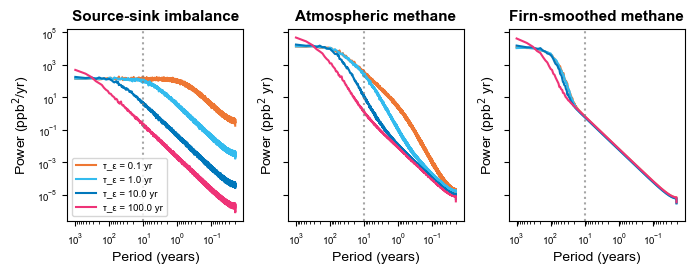

In [19]:
# New 3-column plot: All timescales (0.01 to 100 years) on each plot
# Left: all forcings, Middle: all raw CH4, Right: all smoothed CH4

# Select timescales from 0.1 to 100 years (exclude 1000)
taus_to_plot = [tau for tau in taus_varepsilon if ((tau >= 0.1) & (tau <= 100))]

# Define distinguishable colors for each timescale
import matplotlib.cm as cm

colors_for_taus = [
    colors_vibrant["orange"],
    colors_vibrant["cyan"],
    colors_vibrant["blue"],
    colors_vibrant["magenta"],
    colors_vibrant["red"],
]

fig, axes = plt.subplots(1, 3, figsize=(fig_width, fig_width * 0.4), sharey=True)

# Left plot: All forcings
ax = axes[0]
for idx, tau_varepsilon in enumerate(taus_to_plot):
    psd_data = psd_results[tau_varepsilon]["forcing"]
    ax.loglog(
        psd_data["periods"],
        psd_data["psd"],
        color=colors_for_taus[idx],
        linewidth=1.5,
        label=f"τ_ε = {tau_varepsilon} yr",
    )
ax.axvline(10.0, color="grey", linestyle=":", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Period (years)", fontsize=10)
ax.set_ylabel("Power (ppb$^2$/yr)", fontsize=10)
ax.set_title("Source-sink imbalance", fontsize=11, fontweight="bold")
ax.legend(fontsize=7, loc="best")
ax.grid(False)
ax.invert_xaxis()

# Middle plot: All raw CH4
ax = axes[1]
for idx, tau_varepsilon in enumerate(taus_to_plot):
    psd_data = psd_results[tau_varepsilon]["ch4"]
    ax.loglog(
        psd_data["periods"],
        psd_data["psd"],
        color=colors_for_taus[idx],
        linewidth=1.5,
        label=f"τ_ε = {tau_varepsilon} yr",
    )
ax.axvline(10.0, color="grey", linestyle=":", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Period (years)", fontsize=10)
ax.set_title("Atmospheric methane", fontsize=11, fontweight="bold")
ax.set_ylabel("Power (ppb$^2$ yr)", fontsize=10)
ax.grid(False)
ax.invert_xaxis()

# Right plot: All smoothed CH4
ax = axes[2]
for idx, tau_varepsilon in enumerate(taus_to_plot):
    psd_data = psd_results[tau_varepsilon]["ch4_smooth"]
    ax.loglog(
        psd_data["periods"],
        psd_data["psd"],
        color=colors_for_taus[idx],
        linewidth=1.5,
        label=f"τ_ε = {tau_varepsilon} yr",
    )
ax.axvline(10.0, color="grey", linestyle=":", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Period (years)", fontsize=10)
ax.set_ylabel("Power (ppb$^2$ yr)", fontsize=10)
ax.set_title("Firn-smoothed methane", fontsize=11, fontweight="bold")
ax.grid(False)
ax.invert_xaxis()

plt.tight_layout()
plt.show()
# save figure in pdf format
name = "fast_and_large_variance_psd"
fig.savefig(
    f"{cfg.paths.figures_dir}/for_publication/supplement/{name}.pdf",
    bbox_inches="tight",
    dpi=200,
)